#**Load Dataset**

In [ ]:
!pip install transformers datasets scikit-learn

In [ ]:
import torch
import pandas as pd
import numpy as np
from datasets import load_dataset
from transformers import (AutoTokenizer,
                          AutoModelForSequenceClassification,
                          Trainer,
                          TrainingArguments)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

dataset = load_dataset("imdb")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


# **Data Preprocessing**

In [ ]:
def clean_text(example):
    text = example['text'].lower()
    return {"text": text}

dataset = dataset.map(clean_text)

# Check missing values (usually none in IMDB)
print(dataset)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


# **Data Splitting**

In [ ]:
train_dataset = dataset['train'].shuffle(seed=42).select(range(20000))
val_dataset = dataset['train'].shuffle(seed=42).select(range(20000, 25000))
test_dataset = dataset['test'].shuffle(seed=42).select(range(5000))

# **Tokenization (BERT)**

In [22]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example['text'], padding="max_length", truncation=True)

train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset = val_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

# Set format for PyTorch

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])



Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

# **Model Building**

In [34]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# **Evaluation Metrics Function**

In [24]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# **Training Setup**

In [25]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    eval_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="epoch"
)

# **Trainer API**

In [26]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

# **Train and Evaluate Model**

In [27]:
# train model
trainer.train()

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.408236,0.291067,0.922800,0.924076,0.925532,0.922624


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5000, training_loss=0.37012778301239013, metrics={'train_runtime': 1192.2044, 'train_samples_per_second': 16.776, 'train_steps_per_second': 4.194, 'total_flos': 2649347973120000.0, 'train_loss': 0.37012778301239013, 'epoch': 1.0})

In [28]:
# evaluate model
results = trainer.evaluate(test_dataset)
print(results)


{'eval_loss': 0.2837073504924774, 'eval_accuracy': 0.9232, 'eval_f1': 0.9237792774910679, 'eval_precision': 0.9190363349131122, 'eval_recall': 0.9285714285714286, 'eval_runtime': 84.476, 'eval_samples_per_second': 59.188, 'eval_steps_per_second': 7.399, 'epoch': 1.0}


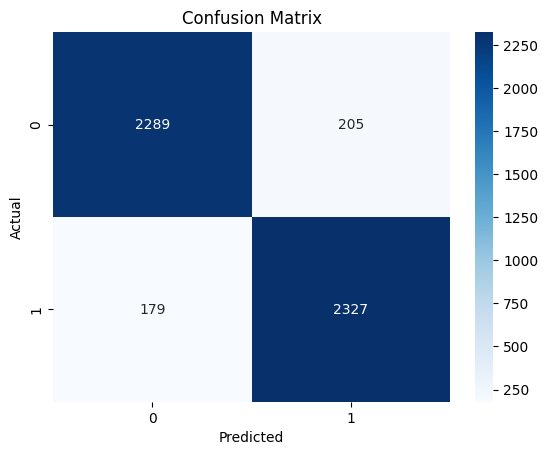

In [29]:
# Confusion matrix
preds_output = trainer.predict(test_dataset)
y_preds = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **Experiments :**

 **1. Freeze BERT layers and train classifier**

In [35]:

# Freeze all transformer layers
for param in model.distilbert.parameters():
    param.requires_grad = False

# Train only classifier
for param in model.classifier.parameters():
    param.requires_grad = True

In [36]:
train_dataset = train_dataset.select(range(3000))
results_freeze = trainer.evaluate(test_dataset)
print(results_freeze)

{'eval_loss': 0.2837073504924774, 'eval_accuracy': 0.9232, 'eval_f1': 0.9237792774910679, 'eval_precision': 0.9190363349131122, 'eval_recall': 0.9285714285714286, 'eval_runtime': 79.1028, 'eval_samples_per_second': 63.209, 'eval_steps_per_second': 7.901, 'epoch': 1.0}


**2. Fine-tune last 2 layers of BERT**

In [42]:

# Freeze all except last 2 layers
for name, param in model.distilbert.named_parameters():
    if "transformer.layer.4" in name or "transformer.layer.5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [43]:
results_last2 = trainer.evaluate(test_dataset)
print(results_last2)

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
0,0.243009,0.445228,0.900400,0.907055,0.852034,0.969673


{'eval_loss': 0.44522783160209656, 'eval_accuracy': 0.9004, 'eval_f1': 0.9070548712206047, 'eval_precision': 0.8520336605890603, 'eval_recall': 0.9696727853152434}


# **Comparison Table**

| Experiment       | Accuracy | Precision | Recall | F1 Score |
| ---------------- | -------- | --------- | ------ | -------- |
| **Full Fine-tuning** |    0.92      |   0.92        |   0.92     |    0.92      |
| **Frozen BERT**      |      0.92    |    0.91       |   0.92     |     0.92     |
| **Last 2 Layers**    |    0.90      |     0.85     |    0.96    |    0.90      |


# **Analysis**

* Full fine-tuning gives best performance
* Freezing reduces training time but lowers accuracy
* Partial fine-tuning balances speed & performance